In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astropy.units as u
from importlib import resources
from matplotlib.ticker import MultipleLocator

## Import

In [2]:

NIR_file = './Data/X-Shooter/1D/stacked_NIR.fits'
UVB_file = './Data/X-Shooter/1D/stacked_UVB.fits'
VIS_file = './Data/X-Shooter/1D/stacked_VIS.fits'

###import data 

with fits.open(NIR_file) as NIR_hdul:
    NIR_hdr = NIR_hdul[1].header
    NIR_data = np.asarray(NIR_hdul[1].data, dtype=float)
    NIR_noise = np.asarray(NIR_hdul[4].data,dtype=float)
crval_NIR = NIR_hdr['CRVAL1'] #Wavelength start point, units of um (microns)
cdelt_NIR = NIR_hdr['CDELT1'] 
crpix_NIR = NIR_hdr.get('CRPIX1') #wavelength reference pixel 
bins_NIR   = np.arange(NIR_data.size)
lam_NIR = crval_NIR + cdelt_NIR * (bins_NIR + 1 - crpix_NIR) # makes sure the array starts at the right place  

with fits.open(UVB_file) as UVB_hdul:
    UVB_hdr = UVB_hdul[1].header
    UVB_data = np.asarray(UVB_hdul[1].data, dtype=float)
    UVB_noise = np.asarray(UVB_hdul[4].data,dtype=float)
crval_UVB = UVB_hdr['CRVAL1'] #Wavelength start point, units of um (microns)
cdelt_UVB = UVB_hdr['CDELT1'] 
crpix_UVB = UVB_hdr.get('CRPIX1') #wavelength reference pixel 
bins_UVB   = np.arange(UVB_data.size)
lam_UVB = crval_UVB + cdelt_UVB * (bins_UVB + 1 - crpix_UVB) # makes sure the array starts at the right place  

with fits.open(VIS_file) as VIS_hdul:
    VIS_hdr = VIS_hdul[1].header
    VIS_data = np.asarray(VIS_hdul[1].data, dtype=float)
    VIS_noise = np.asarray(VIS_hdul[4].data,dtype=float)
crval_VIS = VIS_hdr['CRVAL1'] #Wavelength start point, units of um (microns)
cdelt_VIS = VIS_hdr['CDELT1'] 
crpix_VIS = VIS_hdr.get('CRPIX1') #wavelength reference pixel 
bins_VIS   = np.arange(VIS_data.size)
lam_VIS = crval_VIS + cdelt_VIS * (bins_VIS + 1 - crpix_VIS) # makes sure the array starts at the right place  



In [ ]:
#reference 
ref = np.genfromtxt('./absorption_wls/atoms.dat',dtype=str)

species = ref[:,0]
species_wavelength = ref[:,1].astype(float) #presumably air? 
strength = ref[:,2].astype(float) 
col3 = ref[:,3].astype(float)#what are these? 




## Process Spectra

### Plot and Trim 

In [4]:
### should we convert to angstroms? 
lam_UVB_um = lam_UVB * u.um
lam_VIS_um = lam_VIS * u.um
lam_NIR_um = lam_NIR * u.um

lam_UVB_AA = lam_UVB_um.to(u.AA)
lam_VIS_AA = lam_VIS_um.to(u.AA)
lam_NIR_AA = lam_NIR_um.to(u.AA)

lam_UVB = lam_UVB_AA.value
lam_VIS = lam_VIS_AA.value
lam_NIR = lam_NIR_AA.value

print(lam_NIR[0]) #check that the conversion make sense 


9940.199999999999


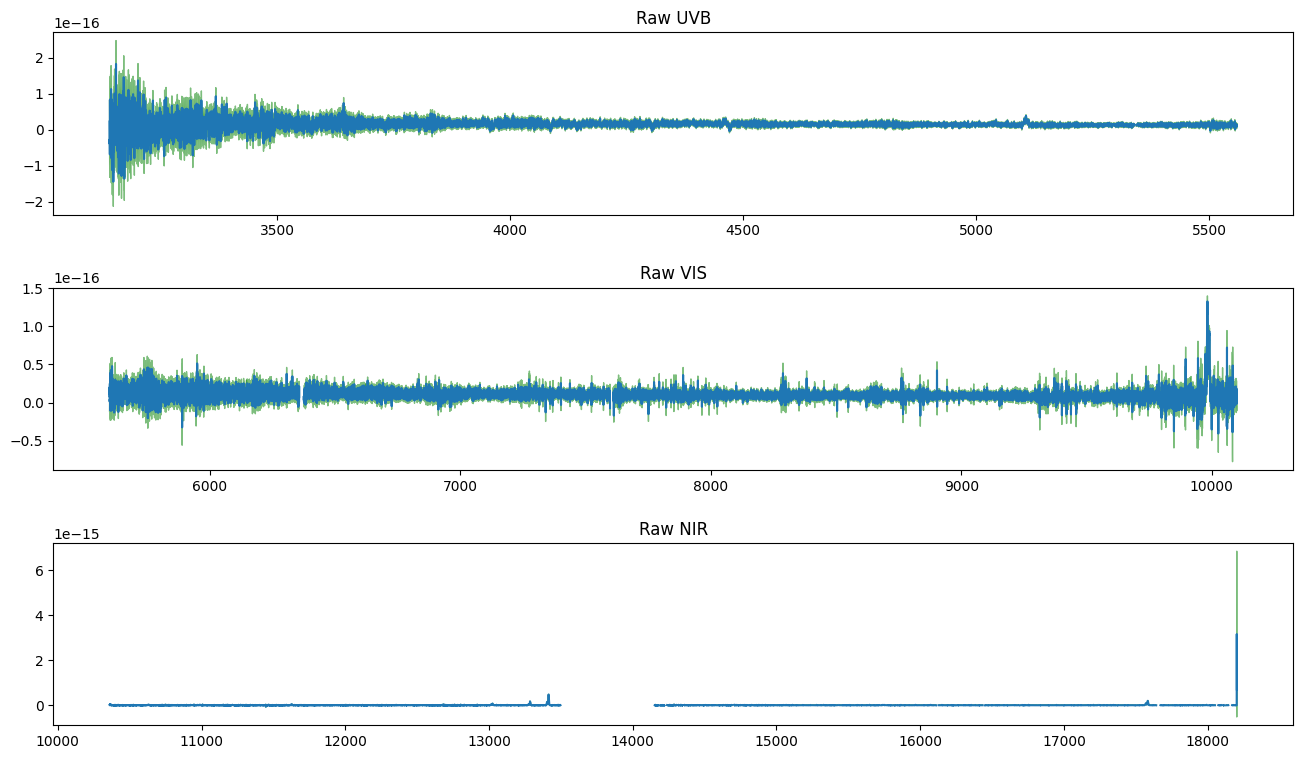

In [5]:
### plot out what it looks like initially 
fig,axes = plt.subplots(3,1,figsize=(16,9),sharex=False,gridspec_kw={"hspace":0.4})

axes[0].plot(lam_UVB,UVB_data)
axes[0].fill_between(
    lam_UVB,
    UVB_data - UVB_noise,
    UVB_data + UVB_noise,
    alpha=0.5,
    color='g',
    label="1 sigma"
)
axes[0].set_title('Raw UVB')

axes[1].plot(lam_VIS,VIS_data)
axes[1].fill_between(
    lam_VIS,
    VIS_data - VIS_noise,
    VIS_data + VIS_noise,
    alpha=0.5,
    color='g',
    label="1 sigma"
)
axes[1].set_title('Raw VIS')

axes[2].plot(lam_NIR,NIR_data)
axes[2].fill_between(
    lam_NIR,
    NIR_data - NIR_noise,
    NIR_data + NIR_noise,
    alpha=0.5,
    color='g',
    label="1 sigma"
)
axes[2].set_title('Raw NIR')

plt.show()


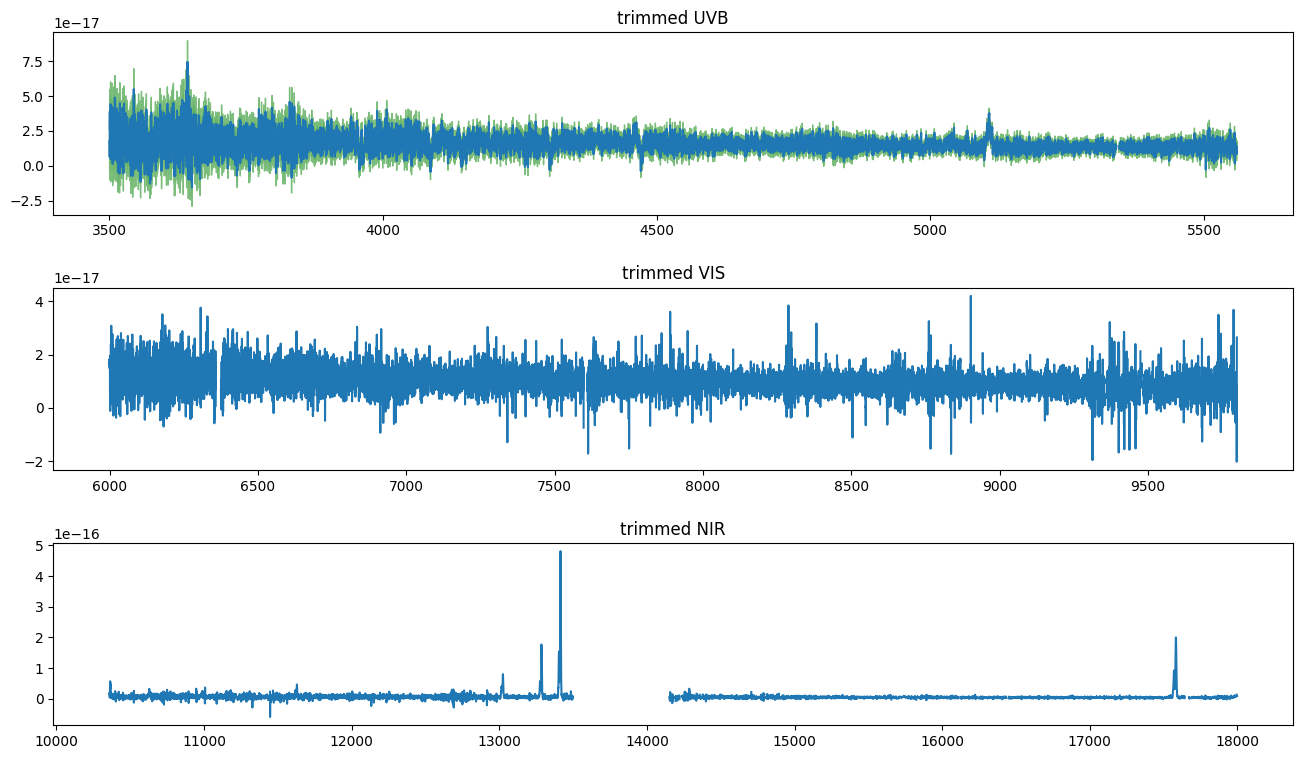

In [6]:
#some trimming 
uvb_lam_mask = (lam_UVB>=3500)&(lam_UVB <=5600) 
lam_uvb_trim = lam_UVB[uvb_lam_mask]
flux_uvb_trim=UVB_data[uvb_lam_mask]
noise_uvb_trim=UVB_noise[uvb_lam_mask]

lam_vis_mask = (lam_VIS>=6000) & (lam_VIS<=9800)
lam_vis_trim = lam_VIS[lam_vis_mask]
flux_vis_trim = VIS_data[lam_vis_mask]
noise_vis_trim=VIS_noise[lam_vis_mask]

lam_nir_mask = (lam_NIR>=lam_NIR[0]) & (lam_NIR<=18000)
lam_nir_trim = lam_NIR[lam_nir_mask]
flux_nir_trim = NIR_data[lam_nir_mask]
noise_nir_trim = NIR_noise[lam_nir_mask]

### plot out what it looks like initially 
fig,axes = plt.subplots(3,1,figsize=(16,9),sharex=False,gridspec_kw={"hspace":0.4})

axes[0].plot(lam_uvb_trim,flux_uvb_trim)
axes[0].fill_between(
    lam_uvb_trim,
    flux_uvb_trim - noise_uvb_trim,
    flux_uvb_trim + noise_uvb_trim,
    alpha=0.5,
    color='g',
    label="1 sigma"
)
axes[0].set_title('trimmed UVB')

axes[1].plot(lam_vis_trim,flux_vis_trim)
axes[1].set_title('trimmed VIS')

axes[2].plot(lam_nir_trim,flux_nir_trim)
axes[2].set_title('trimmed NIR')

plt.show()



### Normalizing

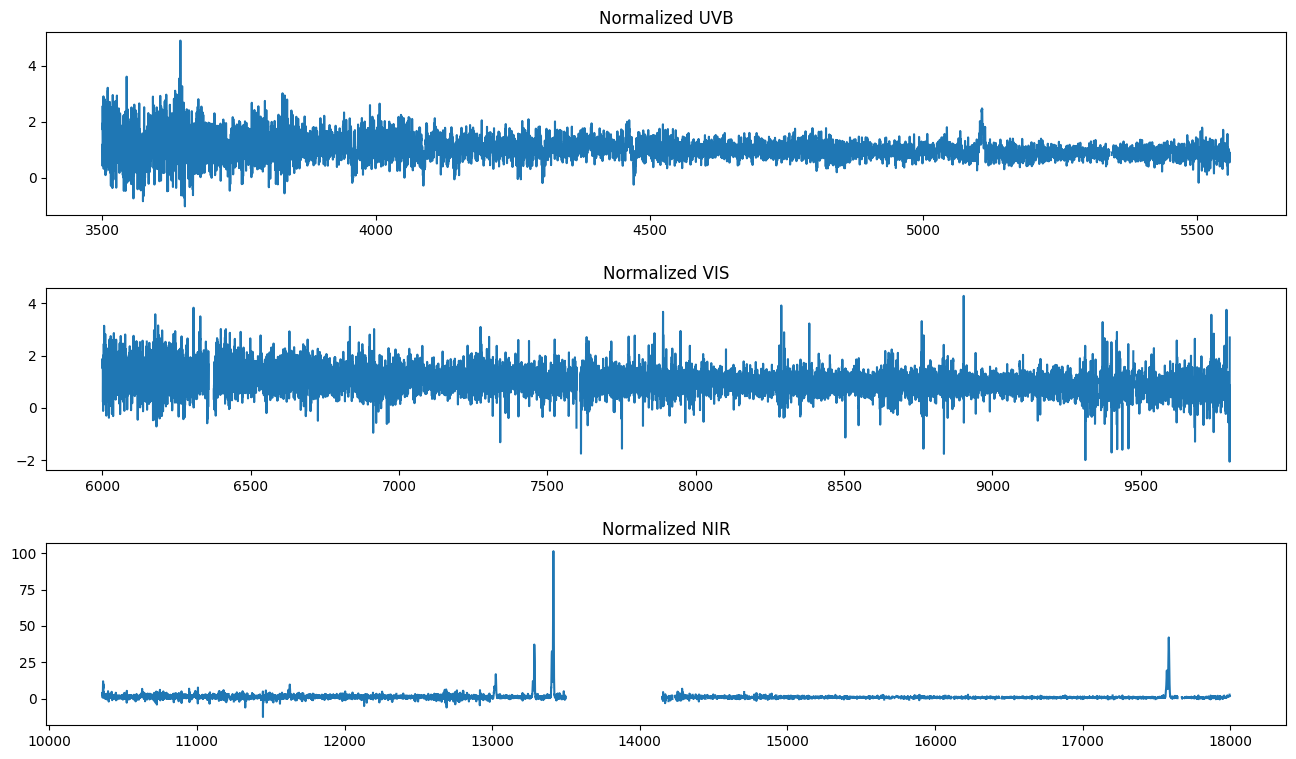

In [7]:
## normalize
scale_UVB = np.nanmedian(flux_uvb_trim)
scale_VIS = np.nanmedian(flux_vis_trim)
scale_NIR = np.nanmedian(flux_nir_trim)


flux_uvb_norm = flux_uvb_trim / scale_UVB 
flux_vis_norm = flux_vis_trim / scale_VIS
flux_nir_norm = flux_nir_trim / scale_NIR

noise_uvb_norm = noise_uvb_trim / scale_UVB
noise_vis_norm = noise_vis_trim / scale_VIS
noise_nir_norm = noise_nir_trim / scale_NIR

fig,axes=plt.subplots(3,1,figsize=(16,9),sharex=False,gridspec_kw={"hspace":0.4})
axes[0].plot(lam_uvb_trim,flux_uvb_norm)
axes[0].set_title('Normalized UVB')

axes[1].plot(lam_vis_trim, flux_vis_norm)
axes[1].set_title('Normalized VIS')

axes[2].plot(lam_nir_trim,flux_nir_norm)
axes[2].set_title('Normalized NIR')

plt.show()

### Smoothing

In [8]:
### checking for NaNs 
nans_flux_UVB = np.isnan(flux_uvb_norm).sum()
nans_flux_VIS = np.isnan(flux_vis_norm).sum()
nans_flux_NIR = np.isnan(flux_nir_norm).sum()
print(f"NaNs in UVB flux: {nans_flux_UVB}")
print(f"NaNs in VIS flux: {nans_flux_VIS}")
print(f"NaNs in NIR flux: {nans_flux_NIR}") #the NIR has this weird thing going on 


#boxcar smoothing with a 5-bin radius 
def boxcar_smooth(flux):
    boxcar = 10 
    radius = boxcar//2
    flux_smooth=np.full_like(flux,np.nan,dtype=float)
    for i in range(len(flux)):
        if np.isnan(flux[i]): #if ur nan then stay nan, works for large areas of nan 
            flux_smooth[i]=np.nan
        else:
            left_bound=max(0,i-radius)
            right_bound = min(len(flux),i+radius)
            flux_smooth[i] = np.nanmedian(flux[left_bound:right_bound]) #ignores nan
    return flux_smooth

flux_uvb_smooth = boxcar_smooth(flux_uvb_norm)
flux_vis_smooth = boxcar_smooth(flux_vis_norm)
flux_nir_smooth = boxcar_smooth(flux_nir_norm) #whole windows are nan so not good 

noise_uvb_smooth = boxcar_smooth(noise_uvb_norm)
noise_vis_smooth = boxcar_smooth(noise_vis_norm)
noise_nir_smooth = boxcar_smooth(noise_nir_norm)



NaNs in UVB flux: 33
NaNs in VIS flux: 743
NaNs in NIR flux: 3854


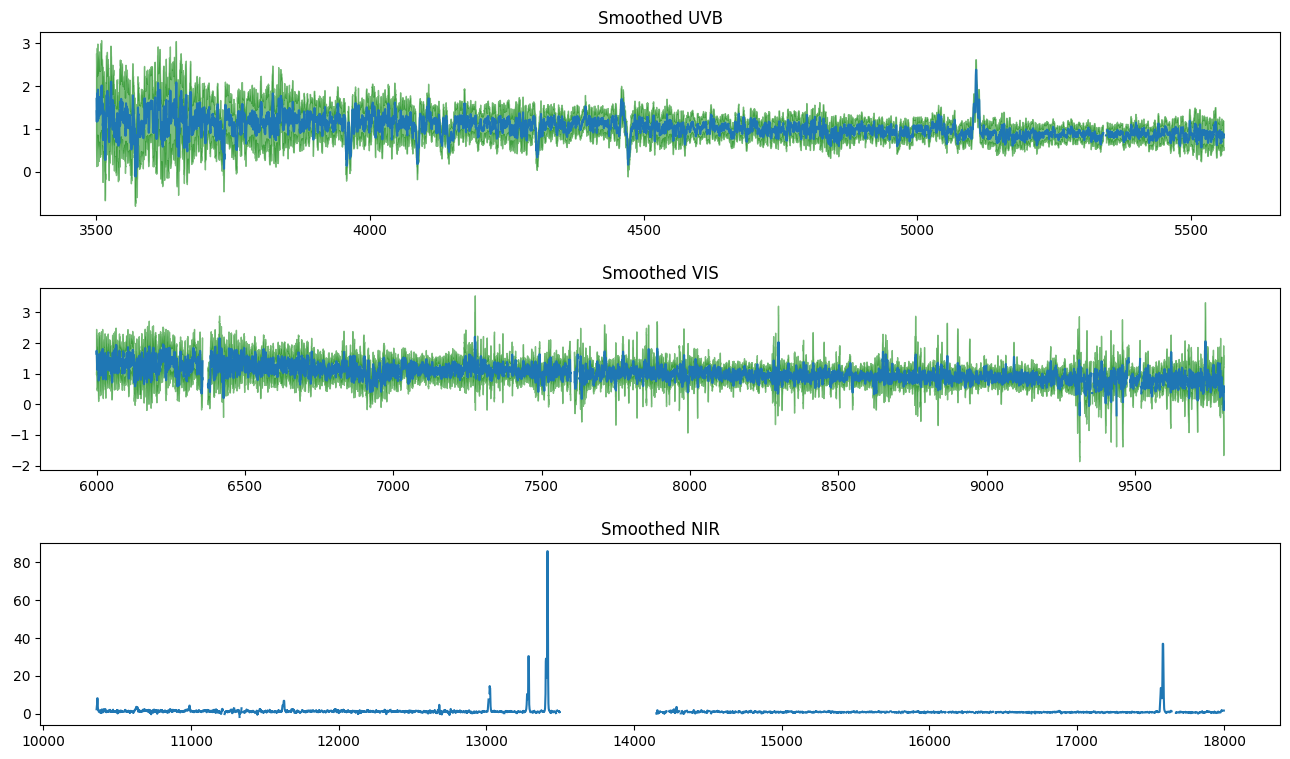

In [9]:
### plot out what it looks like after smoothing
fig,axes = plt.subplots(3,1,figsize=(16,9),sharex=False,gridspec_kw={"hspace":0.4})

axes[0].plot(lam_uvb_trim,flux_uvb_smooth)
axes[0].fill_between(
    lam_uvb_trim,
    flux_uvb_smooth - noise_uvb_smooth,
    flux_uvb_smooth + noise_uvb_smooth,
    alpha=0.5,
    color='g',
    label="1 sigma"
)
axes[0].set_title('Smoothed UVB')

axes[1].plot(lam_vis_trim, flux_vis_smooth)
axes[1].fill_between(
    lam_vis_trim,
    flux_vis_smooth - noise_vis_smooth,
    flux_vis_smooth + noise_vis_smooth,
    alpha=0.5,
    color='g',
    label="1 sigma"
)
axes[1].set_title('Smoothed VIS')

axes[2].plot(lam_nir_trim, flux_nir_smooth)
axes[2].set_title('Smoothed NIR')

plt.show()

## Mark Lines

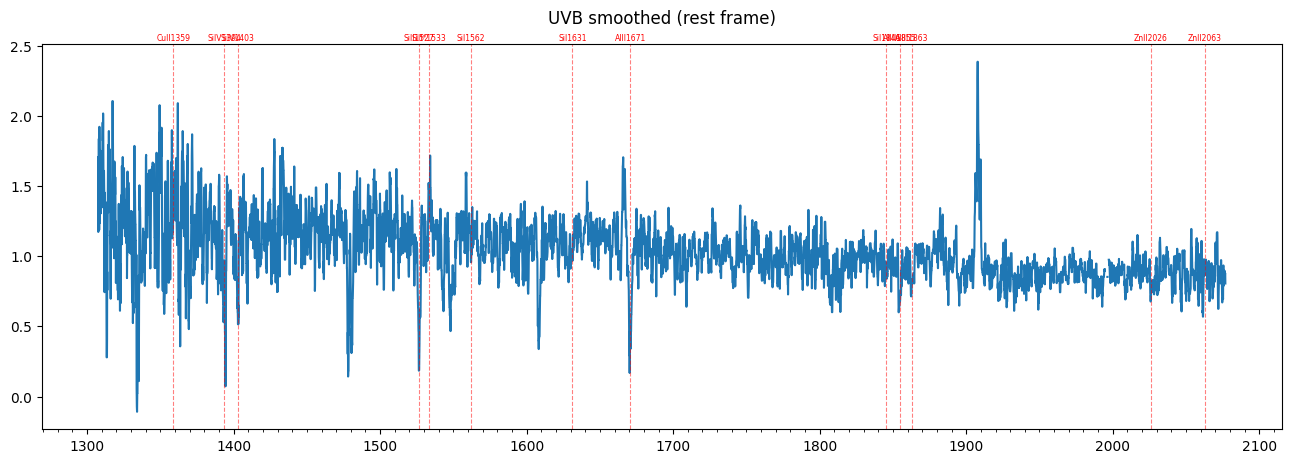

In [10]:
#redshift 
z_A = 1.679 
z_B = 1.677 #this one makes the peaks line up better with the lines 

#make rest-wavelength 
lam_uvb_rest = lam_uvb_trim / (1+z_B)
lam_vis_rest = lam_vis_trim / (1+z_B)
lam_nir_rest = lam_nir_trim / (1+z_B)

#maybe just try UVB first
fig, ax = plt.subplots(figsize=(16, 5))

#plot the absorption lines !
ax.plot(lam_uvb_rest,flux_uvb_smooth)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.set_title('UVB smoothed (rest frame)',pad=15)

#plot the absorption lines !
for i in range(len(species_wavelength)):
    rest_wl = species_wavelength[i]
    if (lam_uvb_rest[0] < rest_wl < lam_uvb_rest[-1])  & (strength[i]>=0.2)  :                                    
        ax.axvline(rest_wl, color='red', ls='--', alpha=0.5, lw=0.8)                  
        ax.text(rest_wl, ax.get_ylim()[1] * 1.01,
                species[i], fontsize=5.5, ha='center', color='red')  
        
plt.show()


In [ ]:
#load in updated reference 
horseshoe_ref = np.genfromtxt('./absorption_wls/horseshoe_atoms.dat',dtype=str)
horseshoe_spec = horseshoe_ref[:,0]
horseshoe_wl = horseshoe_ref[:,1].astype(float)

#load in ism absorption lines
ism_ref = np.genfromtxt('./absorption_wls/ism_atoms.dat',dtype=str)
ism_spec = ism_ref[:,0]
ism_wl = ism_ref[:,1].astype(float)

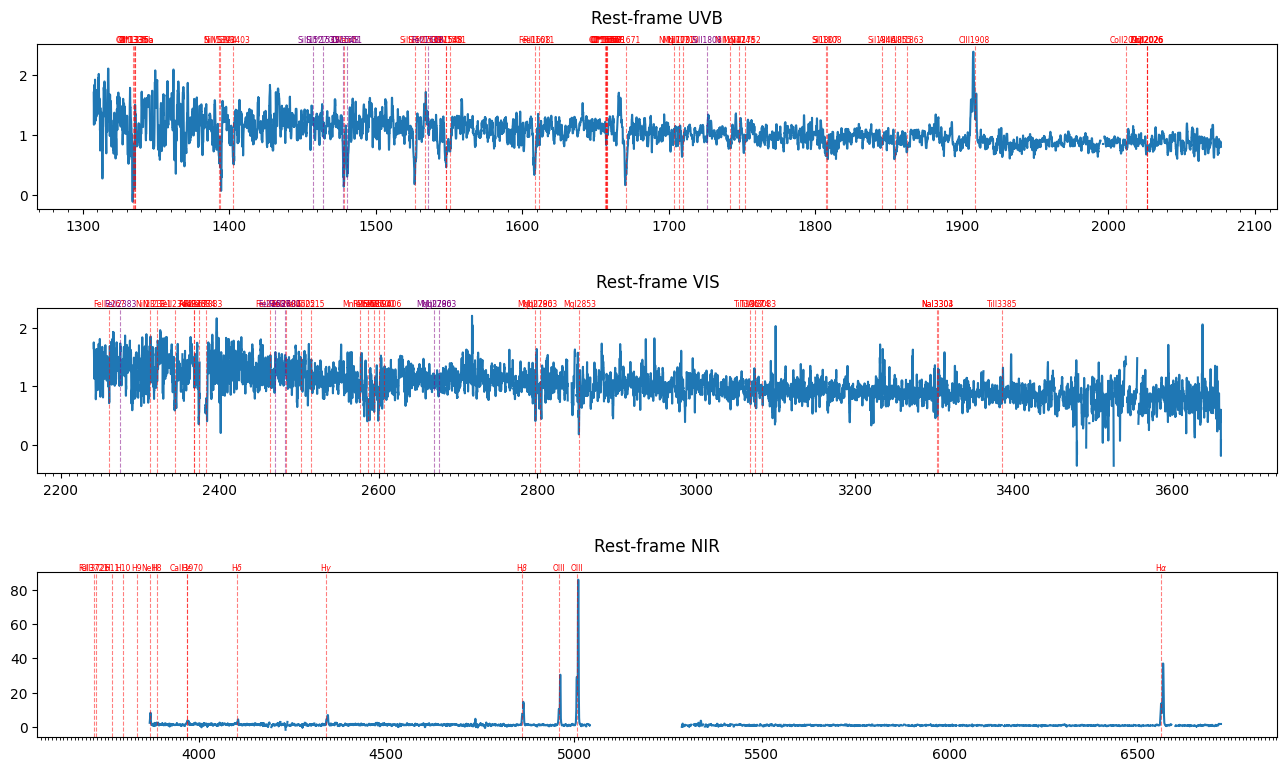

In [12]:

#ism redshift 
z_ism = 1.5553

#set up all-wavelength plot 
fig,axes= plt.subplots(3,1,figsize=(16,9),sharex=False,gridspec_kw={"hspace":0.6})
axes[0].plot(lam_uvb_rest,flux_uvb_smooth)
axes[0].set_title('Rest-frame UVB',pad=15)

axes[1].plot(lam_vis_rest,flux_vis_smooth)
axes[1].set_title('Rest-frame VIS',pad=15)

axes[2].plot(lam_nir_rest,flux_nir_smooth)
axes[2].set_title('Rest-frame NIR',pad=15)

#plot the absorption lines !
for i in range(len(horseshoe_wl)):
    rest_wl = horseshoe_wl[i]
    if (lam_uvb_rest[0] < rest_wl < lam_uvb_rest[-1])  :                                #& (strength[i]>=np.median(strength))         # Only if within UVB wavelength range
        axes[0].axvline(rest_wl, color='red', ls='--', alpha=0.5, lw=0.8) 
        axes[0].xaxis.set_minor_locator(MultipleLocator(10))                   # draws vertical line
        axes[0].text(rest_wl, axes[0].get_ylim()[1] * 1.01,
                horseshoe_spec[i], fontsize=5.5, ha='center', color='red')                           # places name of line at same wavelength
    if (lam_vis_rest[0] < rest_wl < lam_vis_rest[-1]) :                                         # Only if within VIS wavelength range
        axes[1].axvline(rest_wl, color='red', ls='--', alpha=0.5, lw=0.8) 
        axes[1].xaxis.set_minor_locator(MultipleLocator(10))
        axes[1].text(rest_wl, axes[1].get_ylim()[1] * 1.01,
                horseshoe_spec[i], fontsize=5.5, ha='center', color='red')
    if (lam_nir_rest[0] < rest_wl < lam_nir_rest[-1]):                                         # Only if within NIR wavelength range
        axes[2].axvline(rest_wl, color='red', ls='--', alpha=0.5, lw=0.8)
        axes[2].xaxis.set_minor_locator(MultipleLocator(10))
        axes[2].text(rest_wl, axes[2].get_ylim()[1] * 1.01,
                horseshoe_spec[i], fontsize=5.5, ha='center', color='red')
for i in range(len(ism_wl)):
    ism_gal_frame = (ism_wl[i]*(1+z_ism))/(1+z_B)
    if (lam_uvb_rest[0] < ism_gal_frame < lam_uvb_rest[-1])  :                               # Only if within UVB wavelength range
        axes[0].axvline(ism_gal_frame, color='purple', ls='--', alpha=0.5, lw=0.8) 
        axes[0].xaxis.set_minor_locator(MultipleLocator(10))                   # draws vertical line
        axes[0].text(ism_gal_frame, axes[0].get_ylim()[1] * 1.01,
               ism_spec[i], fontsize=5.5, ha='center', color='purple')                           # places name of line at same wavelength
    if (lam_vis_rest[0] <  ism_gal_frame < lam_vis_rest[-1]) :                                         # Only if within VIS wavelength range
        axes[1].axvline( ism_gal_frame, color='purple', ls='--', alpha=0.5, lw=0.8) 
        axes[1].xaxis.set_minor_locator(MultipleLocator(10))
        axes[1].text( ism_gal_frame, axes[1].get_ylim()[1] * 1.01,
                ism_spec[i], fontsize=5.5, ha='center', color='purple')
    if (lam_nir_rest[0] <  ism_gal_frame < lam_nir_rest[-1]):                                         # Only if within NIR wavelength range
        axes[2].axvline( ism_gal_frame, color='purple', ls='--', alpha=0.5, lw=0.8)
        axes[2].xaxis.set_minor_locator(MultipleLocator(10))
        axes[2].text( ism_gal_frame, axes[2].get_ylim()[1] * 1.01,
                ism_spec[i], fontsize=5.5, ha='center', color='purple')
plt.show()

## Update the lines

In [17]:
def zoom_in(left, right, wavelength):
    arms = {
        'UVB': (lam_uvb_rest, flux_uvb_smooth, noise_uvb_smooth),
        'VIS': (lam_vis_rest, flux_vis_smooth, noise_vis_smooth),
        'NIR': (lam_nir_rest, flux_nir_smooth, noise_nir_smooth),
    }
    lam, flux, noise = arms[wavelength]

    lam_zoom_mask = (lam >= left) & (lam <= right)
    lam_zoom = lam[lam_zoom_mask]
    flux_zoom = flux[lam_zoom_mask]
    noise_zoom = noise[lam_zoom_mask]

    fig, ax = plt.subplots(figsize=(16, 9))
    ax.plot(lam_zoom, flux_zoom,ds='steps')

    for i in range(len(horseshoe_wl)):
        rest_wl = horseshoe_wl[i]
        if lam_zoom[0] < rest_wl < lam_zoom[-1]:
            ax.axvline(rest_wl, color='red', ls='--', alpha=0.5, lw=0.8)
            ax.text(rest_wl, 1.01,
                    horseshoe_spec[i], transform=ax.get_xaxis_transform(), fontsize=5.5, ha='center', color='red')
    for i in range(len(ism_wl)):
        ism_gal_frame = ism_wl[i] * (1+z_ism) / (1+z_B)
        if lam_zoom[0] < ism_gal_frame < lam_zoom[-1]:
            ax.axvline(ism_gal_frame, color='purple', ls='--', alpha=0.5, lw=0.8)
            ax.text(ism_gal_frame,1.01,
                    ism_spec[i],  transform=ax.get_xaxis_transform(),fontsize=5.5, ha='center', color='purple')

    ax.fill_between(lam_zoom,flux_zoom-noise_zoom,flux_zoom + noise_zoom,alpha=0.2,color='g',label="1 sigma")
    ax.xaxis.set_minor_locator(MultipleLocator(1))  
    plt.show()


Locator attempting to generate 2147 ticks ([4652.0, ..., 6798.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 2147 ticks ([4652.0, ..., 6798.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 2147 ticks ([4652.0, ..., 6798.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 2147 ticks ([4652.0, ..., 6798.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 2147 ticks ([4652.0, ..., 6798.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 2147 ticks ([4652.0, ..., 6798.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 2147 ticks ([4652.0, ..., 6798.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 2147 ticks ([4652.0, ..., 6798.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 2147 ticks ([4652.0, ..., 6798.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 2147 ticks ([46

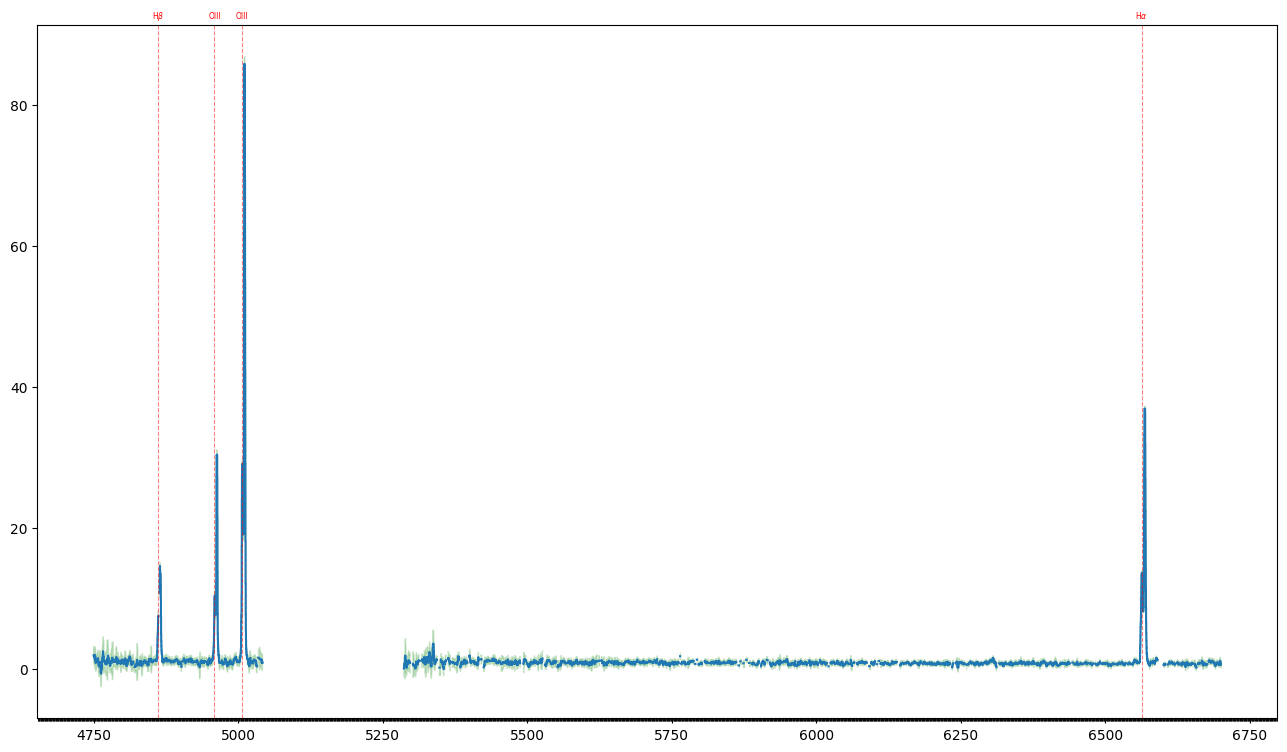

In [25]:
zoom_in(4750,6700,'NIR')